# NB03 - Supervised Baseline

**PCA fitted on labeled training data only (per outer fold).**

This is the reference / control condition.

| | NB03 (this notebook) | NB04 |
|---|---|---|
| PCA fit data | Labeled training fold only | Labeled training + all unlabeled |
| Everything else | identical | identical |

Nested CV: 5-fold outer x 3-fold inner. No leakage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / "data"
REPORTS_DIR  = PROJECT_ROOT / "reports"
FIGURES_DIR  = REPORTS_DIR / "figures"
TABLES_DIR   = REPORTS_DIR / "tables"
for d in [FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED        = 42
OUTER_FOLDS = 5
INNER_FOLDS = 3
VAR_THRESH  = 0.01
COLORS      = {"LumA": "#3498db", "LumB": "#2ecc71", "Her2": "#e74c3c", "Basal": "#9b59b6"}
PARAM_GRID  = {"C": [0.01, 0.1, 1.0, 10.0, 100.0], "l1_ratio": [0.1, 0.5, 0.9]}


## Data Loading

In [3]:
def norm_id(sid):
    sid = str(sid).strip()
    return sid[:15] if sid.startswith("TCGA-") and len(sid) >= 15 else sid

expr = pd.read_csv(DATA_DIR / "HiSeqV2.csv", index_col=0)
if any(str(c).startswith("TCGA-") for c in expr.columns[:10]):
    expr = expr.T
expr.index = [norm_id(s) for s in expr.index]
expr = expr.apply(pd.to_numeric, errors="coerce")

pam = pd.read_csv(DATA_DIR / "brca_pam50.csv")
_SC_COLS = ["Sample", "sample", "sample_id", "SampleID", "TCGA_ID", "bcr_patient_barcode"]
_LC_COLS = ["PAM50", "pam50", "Subtype", "subtype", "BRCA_Subtype_PAM50"]
_sc = next((c for c in _SC_COLS if c in pam.columns), pam.columns[0])
_lc = next((c for c in _LC_COLS if c in pam.columns), None)
if _lc is None:
    _lc = next((c for c in pam.columns
                if "pam" in c.lower() or "subtype" in c.lower()), pam.columns[1])
pam = pam[[_sc, _lc]].copy()
pam.columns = ["sample_id", "subtype"]
pam["sample_id"] = pam["sample_id"].apply(norm_id)
pam = pam[pam["subtype"].notna()]
pam = pam[~pam["subtype"].str.lower().isin(["normal", "normal-like", "nan", "unknown"])]
pam = pam.drop_duplicates("sample_id").set_index("sample_id")

common        = expr.index.intersection(pam.index)
labeled_ids   = common.tolist()
unlabeled_ids = [s for s in expr.index if s not in set(labeled_ids)]
X_labeled     = expr.loc[labeled_ids].values.astype(float)
y_labels      = pam.loc[labeled_ids, "subtype"].values
X_unlabeled   = expr.loc[unlabeled_ids].values.astype(float)
GENE_NAMES    = expr.columns.tolist()
CLASSES       = sorted(set(y_labels))
y_arr         = np.array([CLASSES.index(c) for c in y_labels])
print(f"Labeled: {len(labeled_ids)}  Unlabeled: {len(unlabeled_ids)}  Genes: {len(GENE_NAMES):,}")


Labeled: 73  Unlabeled: 1145  Genes: 20,530


In [4]:
with open(TABLES_DIR / "02_n_components.json") as f:
    nc_data = json.load(f)
N_COMPONENTS = nc_data["N_COMPONENTS"]
print(f"N_COMPONENTS = {N_COMPONENTS}  (from 02_n_components.json)")


N_COMPONENTS = 24  (from 02_n_components.json)


## Nested Cross-Validation

PCA is fit on the labeled training fold only. Outer fold test samples are never seen during preprocessing or PCA fitting.

In [5]:
outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=SEED)

base_clf = LogisticRegression(
    solver="saga",
    class_weight="balanced", max_iter=5000, random_state=SEED,
)

fold_records = []
all_y_true   = []
all_y_pred   = []

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X_labeled, y_arr)):
    X_tr, X_te = X_labeled[train_idx], X_labeled[test_idx]
    y_tr, y_te = y_arr[train_idx], y_arr[test_idx]

    # Preprocessing fit on labeled training fold only
    preproc = Pipeline([
        ("variance", VarianceThreshold(VAR_THRESH)),
        ("scaler",   StandardScaler()),
    ])
    X_tr_scaled = preproc.fit_transform(X_tr)
    X_te_scaled = preproc.transform(X_te)

    # PCA fit on labeled training fold only  <-- supervised baseline
    pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
    X_tr_pca = pca.fit_transform(X_tr_scaled)
    X_te_pca = pca.transform(X_te_scaled)

    gs = GridSearchCV(clone(base_clf), PARAM_GRID, cv=inner_cv,
                      scoring="f1_macro", n_jobs=-1)
    gs.fit(X_tr_pca, y_tr)

    y_pred = gs.predict(X_te_pca)
    f1  = f1_score(y_te, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(y_te, y_pred)

    fold_records.append({
        "fold": fold_i + 1, "f1_macro": round(f1, 4), "accuracy": round(acc, 4),
        "best_C": gs.best_params_["C"], "best_l1": gs.best_params_["l1_ratio"],
        "n_train": len(train_idx), "n_test": len(test_idx),
    })
    all_y_true.extend(y_te.tolist())
    all_y_pred.extend(y_pred.tolist())
    print(f"  Fold {fold_i+1}: F1={f1:.4f}  acc={acc:.4f}")

results_df = pd.DataFrame(fold_records)
print(f"Mean F1: {results_df['f1_macro'].mean():.4f} +/- {results_df['f1_macro'].std():.4f}")


  Fold 1: F1=0.8111  acc=0.8000
  Fold 2: F1=0.9152  acc=0.9333
  Fold 3: F1=0.6867  acc=0.6667
  Fold 4: F1=0.5403  acc=0.6429
  Fold 5: F1=0.6314  acc=0.7857
Mean F1: 0.7169 +/- 0.1480


## Results

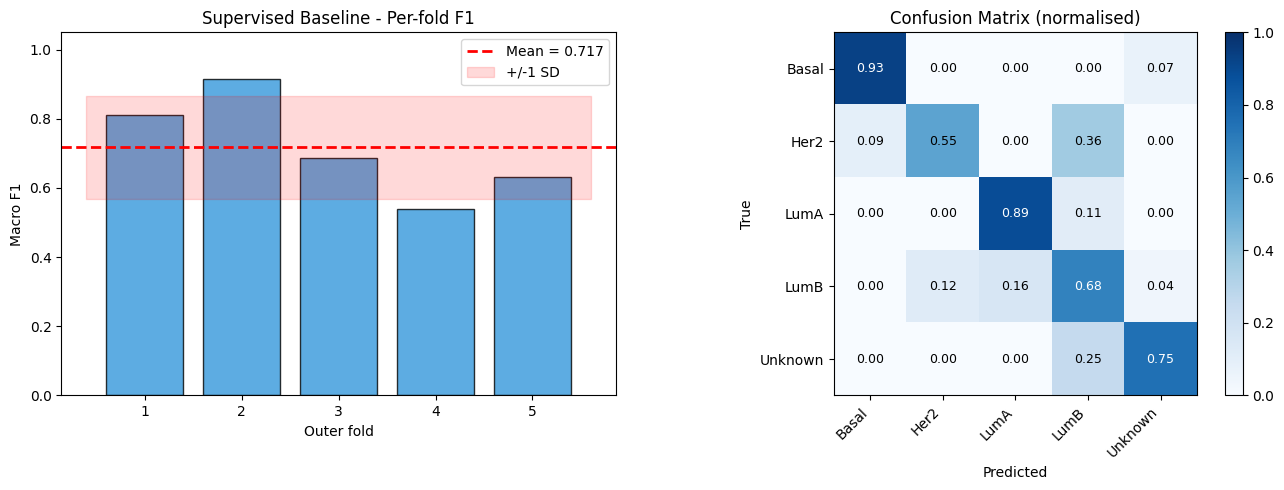

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
mean_f1 = results_df["f1_macro"].mean()
std_f1  = results_df["f1_macro"].std()
ax.bar(results_df["fold"], results_df["f1_macro"],
       color="#3498db", edgecolor="black", alpha=0.8)
ax.axhline(mean_f1, color="red", linestyle="--", lw=2, label=f"Mean = {mean_f1:.3f}")
ax.fill_between([0.4, OUTER_FOLDS + 0.6], mean_f1 - std_f1, mean_f1 + std_f1,
                color="red", alpha=0.15, label="+/-1 SD")
ax.set_xlabel("Outer fold")
ax.set_ylabel("Macro F1")
ax.set_title("Supervised Baseline - Per-fold F1")
ax.set_ylim(0, 1.05)
ax.legend()

cm      = confusion_matrix(all_y_true, all_y_pred, labels=list(range(len(CLASSES))))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ax = axes[1]
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (normalised)")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if cm_norm[i,j] > 0.6 else "black")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()


## Save

In [7]:
results_df.to_csv(TABLES_DIR / "03_baseline_cv_results.csv", index=False)

summary = {
    "pipeline":      "supervised_baseline",
    "pca_fit_on":    "labeled_training_fold_only",
    "N_COMPONENTS":  int(N_COMPONENTS),
    "OUTER_FOLDS":   OUTER_FOLDS,
    "INNER_FOLDS":   INNER_FOLDS,
    "VAR_THRESH":    VAR_THRESH,
    "f1_macro_mean": round(results_df["f1_macro"].mean(), 4),
    "f1_macro_std":  round(results_df["f1_macro"].std(), 4),
    "accuracy_mean": round(results_df["accuracy"].mean(), 4),
    "per_class_f1":  {c: round(f1_score(all_y_true, all_y_pred,
                         labels=[CLASSES.index(c)], average="macro",
                         zero_division=0), 4) for c in CLASSES},
}
with open(TABLES_DIR / "03_baseline_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: 03_baseline_summary.json  +  03_baseline_cv_results.csv")
print(json.dumps(summary, indent=2))


Saved: 03_baseline_summary.json  +  03_baseline_cv_results.csv
{
  "pipeline": "supervised_baseline",
  "pca_fit_on": "labeled_training_fold_only",
  "N_COMPONENTS": 24,
  "OUTER_FOLDS": 5,
  "INNER_FOLDS": 3,
  "VAR_THRESH": 0.01,
  "f1_macro_mean": 0.7169,
  "f1_macro_std": 0.148,
  "accuracy_mean": 0.7657,
  "per_class_f1": {
    "Basal": 0.9333,
    "Her2": 0.6,
    "LumA": 0.8421,
    "LumB": 0.6939,
    "Unknown": 0.6667
  }
}
